Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa López (23764)

# Laboratorio 4 — Parte 1: Obtención de los datos e índices espectrales

Este notebook cubre los **ejercicios 1, 2 y 3** del laboratorio:

1. Establecer la conexión con el API de Sentinel-2 mediante el módulo `openeo`.
2. Descargar únicamente los rásters necesarios para los lagos **Atitlán** y **Amatitlán**.
3. Calcular el **índice de cianobacteria** (Cyano Detection Script de Sentinel Hub), el **NDVI** y el **NDWI**.

El análisis temporal, espacial y comparativo (ejercicios 4 al 8) se desarrolla en el notebook `02_analisis_cianobacteria.ipynb`.

**Preparación del entorno**

Primero se importan las librerías y se agrega la carpeta `src/` al path de Python para poder reutilizar los scripts del proyecto (`config`, `indices`, `mapas`, etc.).

In [ ]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

# La carpeta src/ contiene los scripts
sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import download_sentinel
import indices as ix
import mapas as mp
import procesar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


---

## Ejercicio 1 — Conexión con el API de Sentinel-2

In [2]:
conexion = download_sentinel.conectar()
print("Backend:", config.OPENEO_URL)
print("Usuario:", conexion.describe_account()["name"])

Authenticated using refresh token.
Backend: https://openeo.dataspace.copernicus.eu


Usuario: Sebastian Túnchez


Con la conexión abierta se puede consultar qué colecciones ofrece el backend. En este laboratorio se usan dos productos de Sentinel-2:

| Producto | ¿Qué contiene? | ¿Para qué se usa aquí? |
| --- | --- | --- |
| `SENTINEL2_L1C` | Reflectancia en el tope de la atmósfera | Bandas espectrales que alimentan el script de cianobacteria |
| `SENTINEL2_L2A` | Reflectancia corregida a nivel de superficie | Solo la banda `SCL`, que marca nubes y sombras |

Más adelante se explica por qué las bandas se toman de L1C y no de L2A.

In [3]:
colecciones = [c["id"] for c in conexion.list_collections()]
print("Colecciones Sentinel-2 disponibles en el backend:")
for nombre in sorted(c for c in colecciones if c.startswith("SENTINEL2")):
    print(" -", nombre)

Colecciones Sentinel-2 disponibles en el backend:
 - SENTINEL2_L1C
 - SENTINEL2_L2A


In [4]:
info = conexion.describe_collection("SENTINEL2_L1C")
print("Coleccion:", info["id"])
print("Descripcion:", info["description"].split(".")[0])
print("Bandas disponibles:", info["cube:dimensions"]["bands"]["values"])

Coleccion: SENTINEL2_L1C
Descripcion: SENTINEL-2 is a wide-swath, high-resolution, multi-spectral imaging mission, supporting Copernicus Land Monitoring studies, including the monitoring of vegetation, soil and water cover, as well as observation of inland waterways and coastal areas
Bandas disponibles: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12', 'sunAzimuthAngles', 'sunZenithAngles', 'viewAzimuthMean', 'viewZenithMean']


---

## Ejercicio 2 — Descarga de los rásters necesarios

### Áreas de interés

Las coordenadas de cada lago se encuentran en `src/config.py` y definen el recorte que se le pide al servidor.

In [5]:
for lago, caja in config.BBOX.items():
    ancho_km = (caja["east"] - caja["west"]) * 111.32 * np.cos(np.radians(caja["south"]))
    alto_km = (caja["north"] - caja["south"]) * 110.57
    print(f"{lago:10s} oeste={caja['west']:>10.5f}  este={caja['east']:>10.5f}"
          f"  sur={caja['south']:>9.5f}  norte={caja['north']:>9.5f}"
          f"   ({ancho_km:.1f} x {alto_km:.1f} km)")

Atitlan    oeste= -91.32626  este= -91.07151  sur= 14.59480  norte= 14.75098   (27.4 x 17.3 km)
Amatitlan  oeste= -90.63806  este= -90.51292  sur= 14.41235  norte= 14.49380   (13.5 x 9.0 km)


El siguiente mapa interactivo ayuda a confirmar que los recortes caen sobre los lagos correctos.

In [6]:
import folium

mapa_areas = folium.Map(location=[14.6, -90.95], zoom_start=9, tiles="OpenStreetMap")
colores = {"Atitlan": "#1f77b4", "Amatitlan": "#d62728"}

for lago, caja in config.BBOX.items():
    folium.Rectangle(
        bounds=[[caja["south"], caja["west"]], [caja["north"], caja["east"]]],
        color=colores[lago], weight=3, fill=True, fill_opacity=0.12,
        tooltip=f"Lago de {lago}",
    ).add_to(mapa_areas)

mapa_areas

### Fechas de trabajo

Existen 11 fechas por lago, todas con muy poca nubosidad. Al trabajar con la misma lista para todos los grupos, los resultados son comparables.

In [7]:
filas = []
for lago, fechas in config.FECHAS.items():
    for fecha in fechas:
        filas.append({"lago": lago, "fecha": fecha,
                      "nubosidad_pct": config.NUBOSIDAD[lago][fecha]})

catalogo = pd.DataFrame(filas)
print("Fechas por lago:", catalogo.groupby("lago").size().to_dict())
print("Nubosidad: minima = %.2f%%, maxima = %.2f%%"
      % (catalogo["nubosidad_pct"].min(), catalogo["nubosidad_pct"].max()))
catalogo

Fechas por lago: {'Amatitlan': 11, 'Atitlan': 11}
Nubosidad: minima = 0.01%, maxima = 13.00%


,lago,fecha,nubosidad_pct
0,Atitlan,2025-01-18,0.02
1,Atitlan,2025-04-13,0.54
2,Atitlan,2025-05-13,4.37
3,Atitlan,2025-07-17,3.57
4,Atitlan,2025-11-21,3.15
5,Atitlan,2025-12-29,3.17
6,Atitlan,2026-02-12,0.04
7,Atitlan,2026-03-24,3.17
8,Atitlan,2026-04-13,0.01
9,Atitlan,2026-04-28,4.96


### Bandas solicitadas

Se descargan solo las bandas indispensables.

| Banda | Longitud de onda | ¿Para qué se necesita? |
| --- | --- | --- |
| B02 (azul) | 490 nm | Máscara de agua del script |
| B03 (verde) | 560 nm | **NDWI**, máscara de agua |
| B04 (rojo) | 665 nm | **NDVI**, **NDCI**, FAI |
| B05 (borde rojo) | 705 nm | **NDCI** (clorofila-a) |
| B07 (borde rojo) | 783 nm | FAI |
| B08 (NIR) | 842 nm | **NDVI**, **NDWI** |
| B8A (NIR estrecho) | 865 nm | FAI |
| B11 (SWIR) | 1610 nm | Máscara de agua |
| B12 (SWIR) | 2190 nm | Máscara de agua |
| SCL (L2A) | — | Descartar nubes y sombras |

Además se fija la salida en **EPSG:32615** (UTM 15N, que cubre ambos lagos) con píxeles de **20 m**. Fijar la proyección y la resolución garantiza que todas las fechas de un mismo lago compartan exactamente la misma malla de píxeles, lo que después permite compararlas píxel a píxel.

In [8]:
print("Bandas L1C:", config.BANDAS_L1C)
print("Bandas L2A:", config.BANDAS_L2A)
print("Proyeccion de salida:", config.CRS_SALIDA)
print("Resolucion:", config.RESOLUCION_M, "m")

Bandas L1C: ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12']
Bandas L2A: ['SCL']
Proyeccion de salida: EPSG:32615
Resolucion: 20 m


### Descarga

La función `descargar()` de `src/download_sentinel.py` arma el *cubo de datos*, lo recorta y lo baja como GeoTIFF. Es idempotente (si el archivo ya existe, lo omite).

In [9]:
download_sentinel.main(list(config.FECHAS))

Authenticated using refresh token.

=== Atitlan ===
  [omitido] ya existe Atitlan_2025-01-18_L1C.tif
  [omitido] ya existe Atitlan_2025-01-18_L2A.tif
  [omitido] ya existe Atitlan_2025-04-13_L1C.tif
  [omitido] ya existe Atitlan_2025-04-13_L2A.tif
  [omitido] ya existe Atitlan_2025-05-13_L1C.tif
  [omitido] ya existe Atitlan_2025-05-13_L2A.tif
  [omitido] ya existe Atitlan_2025-07-17_L1C.tif
  [omitido] ya existe Atitlan_2025-07-17_L2A.tif
  [omitido] ya existe Atitlan_2025-11-21_L1C.tif
  [omitido] ya existe Atitlan_2025-11-21_L2A.tif
  [omitido] ya existe Atitlan_2025-12-29_L1C.tif
  [omitido] ya existe Atitlan_2025-12-29_L2A.tif
  [omitido] ya existe Atitlan_2026-02-12_L1C.tif
  [omitido] ya existe Atitlan_2026-02-12_L2A.tif
  [omitido] ya existe Atitlan_2026-03-24_L1C.tif
  [omitido] ya existe Atitlan_2026-03-24_L2A.tif
  [omitido] ya existe Atitlan_2026-04-13_L1C.tif
  [omitido] ya existe Atitlan_2026-04-13_L2A.tif
  [omitido] ya existe Atitlan_2026-04-28_L1C.tif
  [omitido] ya ex

In [10]:
inventario = []
for lago in config.FECHAS:
    for archivo in sorted((config.DATA_RAW / lago).glob("*.tif")):
        inventario.append({
            "lago": lago,
            "archivo": archivo.name,
            "MB": round(archivo.stat().st_size / 1e6, 1),
        })

inventario = pd.DataFrame(inventario)
print("Archivos descargados:", len(inventario))
print("Peso total: %.0f MB" % inventario["MB"].sum())
inventario.groupby("lago")["MB"].agg(["count", "sum"])

Archivos descargados: 44
Peso total: 552 MB


,count,sum
lago,,
Amatitlan,22,96.5
Atitlan,22,455.2


Cada GeoTIFF descargado se puede abrir con `rasterio` para verificar su geometría.

In [11]:
ejemplo = config.DATA_RAW / "Atitlan" / "Atitlan_2026-04-13_L1C.tif"
with rasterio.open(ejemplo) as src:
    print("Archivo   :", ejemplo.name)
    print("Proyeccion:", src.crs)
    print("Tamano    :", src.height, "filas x", src.width, "columnas")
    print("Bandas    :", src.count, "->", src.descriptions)
    print("Tipo dato :", src.dtypes[0])
    print("Resolucion:", src.res, "metros")

Archivo   : Atitlan_2026-04-13_L1C.tif
Proyeccion: EPSG:32615
Tamano    : 876 filas x 1380 columnas
Bandas    : 9 -> ('B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12')
Tipo dato : int16
Resolucion: (20.0, 20.0) metros


### Visualización de la imagen descargada (color verdadero)

Antes de calcular índices conviene mirar la imagen tal como la vería el ojo humano, combinando las bandas roja, verde y azul. Los valores de Sentinel-2 vienen como enteros que hay que dividir entre 10 000 para obtener reflectancia entre 0 y 1, y luego estirar el contraste para que la imagen se vea bien.

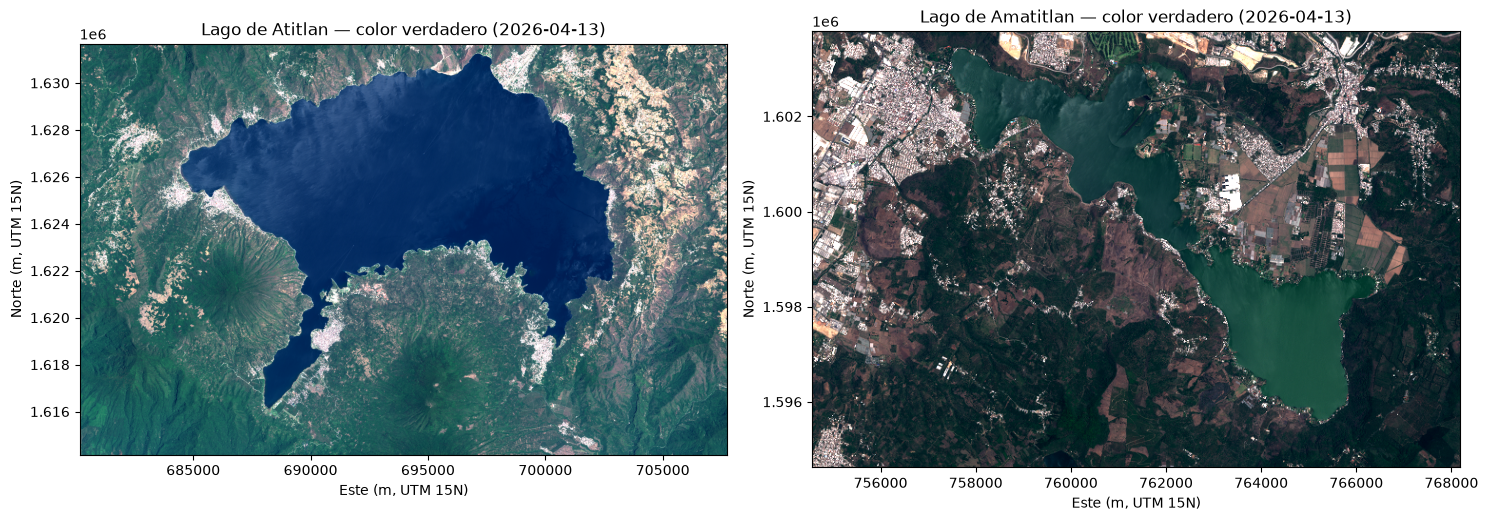

In [12]:
def color_verdadero(lago, fecha):
    ruta = config.DATA_RAW / lago / f"{lago}_{fecha}_L1C.tif"
    bandas = ix.leer_bandas(ruta, config.DATA_RAW / lago / f"{lago}_{fecha}_L2A.tif")
    rgb = np.dstack([bandas["B04"], bandas["B03"], bandas["B02"]])
    # Estiramiento de contraste entre los percentiles 2 y 98
    p2, p98 = np.nanpercentile(rgb, (2, 98))
    return np.clip((rgb - p2) / (p98 - p2), 0, 1)


escenas = {"Atitlan": "2026-04-13", "Amatitlan": "2026-04-13"}

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
for eje, (lago, fecha) in zip(ejes, escenas.items()):
    eje.imshow(color_verdadero(lago, fecha), extent=mp.extent_utm(
        config.DATA_RAW / lago / f"{lago}_{fecha}_L1C.tif"))
    eje.set_title(f"Lago de {lago} — color verdadero ({fecha})")
    eje.set_xlabel("Este (m, UTM 15N)")
    eje.set_ylabel("Norte (m, UTM 15N)")
plt.tight_layout()
plt.show()

Se distinguen con claridad los dos lagos. **Atitlán** es mucho más grande y está rodeado de montañas y volcanes; su agua se ve azul oscuro, señal de un agua profunda y limpia. **Amatitlán** es pequeño, alargado, con la ciudad y la carretera pegadas a su orilla, y su agua se ve notoriamente más clara y verdosa, lo que ya sugiere más material en suspensión y más algas.

---

## Ejercicio 3 — Índice de cianobacteria, NDVI y NDWI

### Los tres índices

Un **índice espectral** es una resta y una división entre bandas. La idea es siempre la misma, se debe elegir dos bandas donde el objeto de interés se comporte de forma opuesta, para que el contraste se amplifique.

| Índice | Fórmula | ¿Qué mide? |
| --- | --- | --- |
| **NDVI** | (B08 − B04) / (B08 + B04) | Vigor de la vegetación |
| **NDWI** | (B03 − B08) / (B03 + B08) | Presencia de agua |
| **NDCI** | (B05 − B04) / (B05 + B04) | Clorofila-a en el agua (base del índice de cianobacteria) |

### El custom script de cianobacteria

El índice de cianobacteria se toma del script publicado en
[custom-scripts.sentinel-hub.com — *Cyanobacteria Chlorophyll-a NDCI*](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/) (Kravitz & Matthews, 2020). El script original es JavaScript y hace cuatro cosas:

1. **Máscara de agua (`wbi`)**: combina seis índices de agua (MNDWI, NDWI, AWEI, NDVI…) para decidir si un píxel es agua, y luego descarta zonas urbanas y suelo desnudo mal clasificados. Solo los píxeles de agua se analizan.

2. **NDCI**: $(B05 − B04) / (B05 + B04)$.

3. **Clorofila-a**: convierte el NDCI a concentración con un polinomio calibrado:
$chl-a = 826.57 \cdot NDCI^{3} − 176.43 \cdot NDCI^{2} + 19 \cdot NDCI + 4.071$ (mg/m³).

4. **FAI** (*Floating Algae Index*): $B07 − B04 − (B8A − B04) \cdot (783−665)/(865−665)$. Si supera 0.08, el script marca el píxel como **nata de algas flotando en superficie**.

En este laboratorio el script se reimplementó en Python (`src/indices.py`) usando NumPy, conservando exactamente las mismas fórmulas y umbrales.

**¿Por qué se usan las bandas de L1C?**

El script está escrito para **L1C** (reflectancia en el tope de la atmósfera). Sus umbrales de máscara de agua (MNDWI > 0.42, NDWI > 0.4) asumen esos valores, que son más altos porque incluyen la dispersión atmosférica. Al aplicarlos sobre L2A (corregido a superficie), el agua muy oscura y limpia de Atitlán queda por debajo de los umbrales y el script solo reconocía como agua una fracción del lago. Por eso las bandas espectrales se toman de L1C, tal como fue diseñado el script, y de L2A se usa solo la banda `SCL`
para descartar nubes y sombras.

In [13]:
def demo_indices(lago, fecha):
    capas = ix.calcular_indices(
        config.DATA_RAW / lago / f"{lago}_{fecha}_L1C.tif",
        config.DATA_RAW / lago / f"{lago}_{fecha}_L2A.tif",
    )
    return capas


demo = {lago: demo_indices(lago, fecha) for lago, fecha in escenas.items()}

for lago, capas in demo.items():
    agua = capas["agua"]
    print(f"{lago} ({escenas[lago]}): {agua.sum():,} pixeles de agua "
          f"= {agua.sum() * 0.0004:.1f} km2")

Atitlan (2026-04-13): 304,666 pixeles de agua = 121.9 km2
Amatitlan (2026-04-13): 36,901 pixeles de agua = 14.8 km2


Las áreas detectadas son coherentes con la realidad, el lago de Atitlán tiene alrededor de 130 km² y el de Amatitlán alrededor de 15 km².

### Mapas de los tres índices

Cada índice se dibuja solo sobre los píxeles de agua. La escala de clorofila-a es distinta para cada lago (0–5 mg/m³ en Atitlán y 0–25 mg/m³ en Amatitlán) porque sus niveles son de otro orden de magnitud; con una
escala común, Atitlán se vería completamente plano.

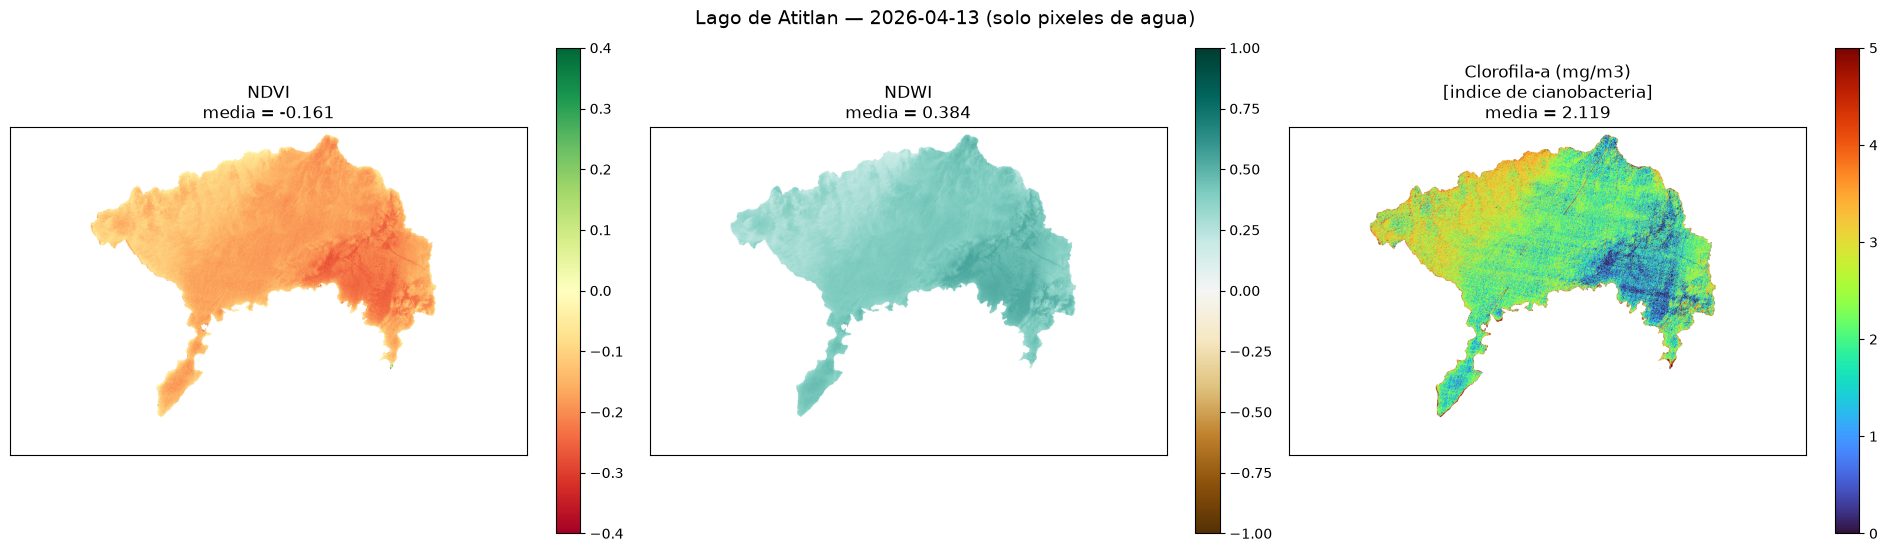

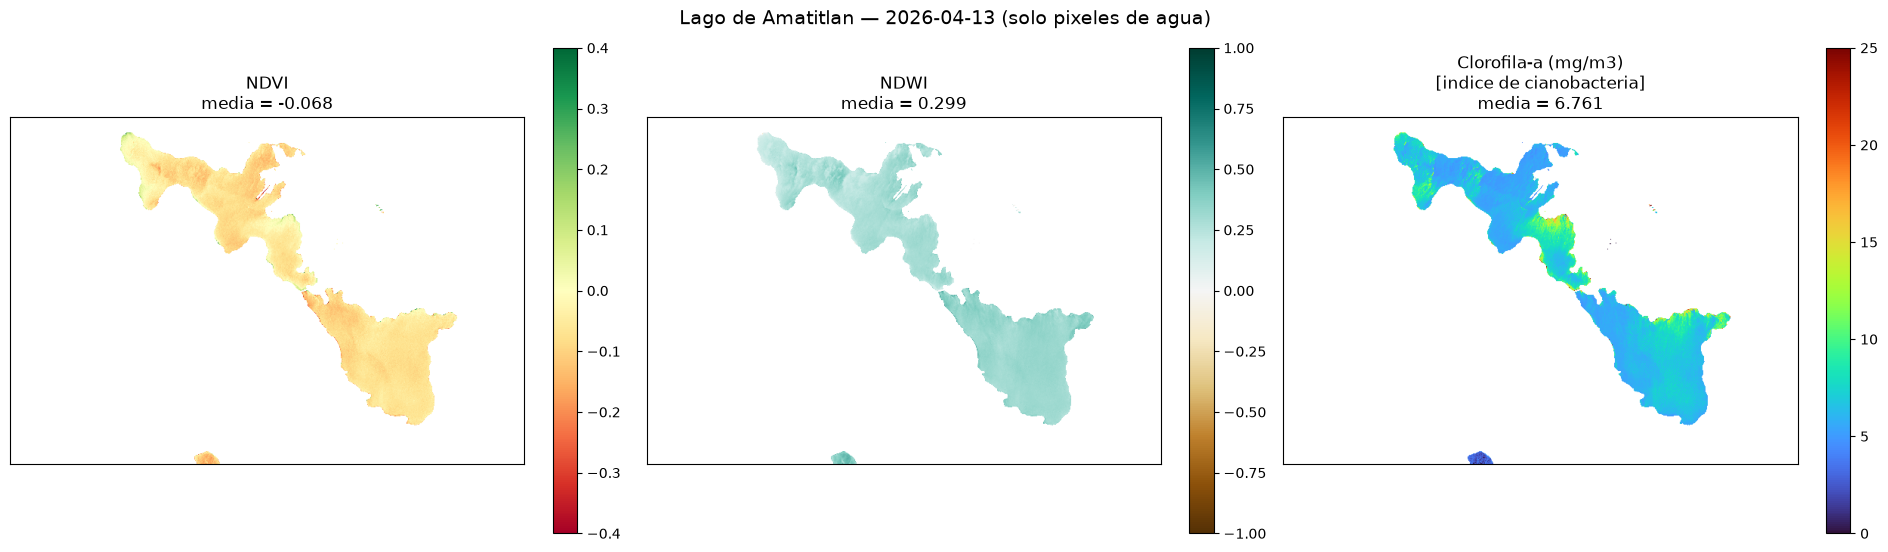

In [14]:
ESCALA_CHLA = {"Atitlan": (0, 5), "Amatitlan": (0, 25)}


def mapa_indices(lago, fecha, capas):
    ruta = config.DATA_RAW / lago / f"{lago}_{fecha}_L1C.tif"
    extension = mp.extent_utm(ruta)
    agua = capas["agua"]

    definicion = [
        ("ndvi", "NDVI", "RdYlGn", -0.4, 0.4),
        ("ndwi", "NDWI", "BrBG", -1, 1),
        ("chla", "Clorofila-a (mg/m3)\n[indice de cianobacteria]", "turbo",
         *ESCALA_CHLA[lago]),
    ]

    fig, ejes = plt.subplots(1, 3, figsize=(19, 5.5))
    for eje, (clave, titulo, cmap, vmin, vmax) in zip(ejes, definicion):
        capa = np.where(agua, capas[clave], np.nan)
        img = eje.imshow(capa, cmap=cmap, vmin=vmin, vmax=vmax, extent=extension)
        eje.set_title(f"{titulo}\nmedia = {np.nanmean(capa):.3f}")
        eje.set_xticks([])
        eje.set_yticks([])
        fig.colorbar(img, ax=eje, fraction=0.046)
    fig.suptitle(f"Lago de {lago} — {fecha} (solo pixeles de agua)", fontsize=14)
    plt.tight_layout()
    plt.show()


for lago, fecha in escenas.items():
    mapa_indices(lago, fecha, demo[lago])

**¿Qué se observa en estos mapas?**

- **NDVI**: negativo en los dos lagos, como corresponde al agua, que absorbe el infrarrojo. Atitlán es más negativo que Amatitlán, es decir, su agua está más "limpia" desde el punto de vista óptico.

- **NDWI**: bastante positivo y bastante uniforme en ambos lagos (confirma que la máscara de agua está bien puesta). Atitlán muestra valores más altos que Amatitlán.

- **Clorofila-a**: Atitlán se mantiene en torno a 2 mg/m³ con un gradiente suave, mientras que Amatitlán ronda los 7 mg/m³, es decir, varias veces más, y muestra zonas más marcadas cerca de las orillas.

### Procesamiento de todas las fechas

Ya validado el cálculo, se aplica a las 22 escenas. El script `src/procesar.py`:

1. calcula los cinco índices por escena y los guarda en `data/processed/`;
2. construye una **máscara fija del lago** (píxeles que son agua en al menos el 60% de las fechas), para que todas las fechas se comparen sobre la misma superficie;
3. genera la tabla de estadísticas por lago y fecha.

In [15]:
procesar.main()

=== Atitlan: indices ===


  [ok] 2025-01-18


  [ok] 2025-04-13


  [ok] 2025-05-13


  [ok] 2025-07-17


...

  [ok] 2026-04-28


  [ok] 2026-06-19


Atitlan: espejo de agua = 122.0 km2


Amatitlan: espejo de agua = 14.6 km2



Guardado: /home/sebas/github/Data-Science/CC3084-Laboratorio-4/data/processed/estadisticas_por_fecha.csv
         lago      fecha  nubosidad_pct  area_lago_km2  cobertura_valida_pct  pixeles_analizados  ndci_medio  chla_media  chla_mediana   chla_p90    chla_max  ndvi_medio  ndwi_medio   pct_alto  \
0   Amatitlan 2025-01-28           0.06        14.6364            100.000000               36591    0.028931    4.441269      4.483237   4.750260   31.263718   -0.225159    0.461389   0.040994   
1   Amatitlan 2025-04-15           0.09        14.6364            100.000000               36591    0.049095    4.573547      4.589940   5.931573   33.884399   -0.103468    0.293673   0.076522   
2   Amatitlan 2025-04-28           1.03        14.6364            100.000000               36591    0.091686    5.863078      4.891214   9.151348   65.616844   -0.079704    0.290377   0.866333   
3   Amatitlan 2025-11-24           0.50        14.6364             99.849690               36536    0.021351  

### Tabla resumen

La tabla que queda en `data/processed/estadisticas_por_fecha.csv` es el insumo del segundo notebook. Sus columnas principales son:

- `cobertura_valida_pct`: qué porcentaje del lago quedó libre de nubes esa fecha.
- `ndci_medio`, `chla_media`, `chla_mediana`, `chla_p90`, `chla_max`: nivel de cianobacteria.
- `pct_alto`: porcentaje del lago con clorofila-a ≥ 20 mg/m³.
- `pct_fai_alto`: porcentaje del lago con nata de algas en superficie (FAI > 0.08).

In [ ]:
tabla = pd.read_csv(config.DATA_PROCESSED / "estadisticas_por_fecha.csv", parse_dates=["fecha"])
tabla.round(3)

,lago,fecha,nubosidad_pct,area_lago_km2,cobertura_valida_pct,pixeles_analizados,ndci_medio,chla_media,chla_mediana,chla_p90,chla_max,ndvi_medio,ndwi_medio,pct_alto,pct_fai_alto
0,Amatitlan,2025-01-28,0.06,14.636,100.000,36591,0.029,4.441,4.483,4.750,31.264,-0.225,0.461,0.041,0.052
1,Amatitlan,2025-04-15,0.09,14.636,100.000,36591,0.049,4.574,4.590,5.932,33.884,-0.103,0.294,0.077,0.068
2,Amatitlan,2025-04-28,1.03,14.636,100.000,36591,0.092,5.863,4.891,9.151,65.617,-0.080,0.290,0.866,0.235
3,Amatitlan,2025-11-24,0.50,14.636,99.850,36536,0.021,4.751,4.009,5.151,113.828,-0.214,0.432,1.177,0.443
4,Amatitlan,2026-01-08,0.77,14.636,100.000,36591,0.101,6.936,4.889,7.873,149.967,-0.107,0.358,3.501,0.686
5,Amatitlan,2026-02-02,0.39,14.636,96.502,35311,0.020,4.295,4.410,4.712,16.494,-0.109,0.297,0.000,0.003
6,Amatitlan,2026-02-07,0.02,14.636,100.000,36591,0.022,4.304,4.444,4.736,17.756,-0.149,0.366,0.000,0.000
7,Amatitlan,2026-03-29,0.01,14.636,100.000,36591,0.129,6.444,5.240,8.214,82.327,-0.100,0.321,2.834,0.030
8,Amatitlan,2026-04-13,0.09,14.636,99.995,36589,0.172,6.743,6.395,8.651,36.592,-0.068,0.299,0.063,0.000
9,Amatitlan,2026-04-28,4.96,14.636,94.971,34751,0.156,10.395,6.810,22.541,62.454,0.028,0.221,13.654,2.466
